---
title: "Rank & the four fundamental subspaces"
categories: []
---


A matrix $\mathbf{A}\in\mathbb{R}^{m\times n}$ turns vectors in $\mathbb{R}^n$ into vectors in $\mathbb{R}^m$. The single most informative integer attached to it is its **rank** $r$: the dimension of its image, the number of genuinely independent directions it can produce. This chapter develops rank from three complementary angles: abstract (dimension is well-defined), algebraic (the rank-nullity theorem and the equality of row and column rank), and computational (rank as the count of nonzero singular values, with the numerical caveats that follow). It then assembles the **four fundamental subspaces** of $\mathbf{A}$ and shows they decompose the input space $\mathbb{R}^n$ and the output space $\mathbb{R}^m$ into orthogonal pieces, giving the cleanest description of what a matrix *does*.


## Rank

The **column rank** of $\mathbf{A}$ is the dimension of its column space $\mathsf{C}(\mathbf{A})$, the largest number of linearly independent columns. The **row rank** is the dimension of the row space $\mathsf{C}(\mathbf{A}^{\mathsf T})$, the largest number of linearly independent rows. Both are bounded by the shape of $\mathbf{A}$:

$$0 \le \text{rank}(\mathbf{A}) \le \min(m,n).$$

A matrix with $r=\min(m,n)$ has **full rank**; otherwise it is **rank-deficient**. Before proving that the two ranks always agree, the notion of *dimension* itself must be pinned down, which requires the exchange lemma.


**Exchange lemma (Steinitz).** Let $\mathbf{u}_1,\dots,\mathbf{u}_s$ be linearly independent and let $\mathbf{v}_1,\dots,\mathbf{v}_t$ span a vector space $V$. Then $s\le t$.

**Proof.** Maintain a spanning list of fixed length $t$. Start with $\mathbf{v}_1,\dots,\mathbf{v}_t$. Since $\mathbf{u}_1\in V$, the list $\mathbf{u}_1,\mathbf{v}_1,\dots,\mathbf{v}_t$ is linearly dependent; by the linear dependence lemma (a list is dependent iff some member lies in the span of its predecessors), some member is a combination of earlier ones. It cannot be $\mathbf{u}_1$, which has no predecessors and is nonzero, so it is some $\mathbf{v}_j$. Removing it still spans $V$ (the removed vector was redundant). Reindex the survivors as $\mathbf{v}_2,\dots,\mathbf{v}_t$; the spanning list is now $\mathbf{u}_1,\mathbf{v}_2,\dots,\mathbf{v}_t$.

Repeat. After inserting $\mathbf{u}_1,\dots,\mathbf{u}_{k-1}$, write $\mathbf{u}_k$ against the current spanning list $\mathbf{u}_1,\dots,\mathbf{u}_{k-1},\mathbf{v}_k,\dots,\mathbf{v}_t$:

$$\mathbf{u}_k = \sum_{i<k} c_i \mathbf{u}_i + \sum_{j\ge k} d_j \mathbf{v}_j.$$

Some $d_j$ is nonzero, else $\mathbf{u}_k$ would be a combination of $\mathbf{u}_1,\dots,\mathbf{u}_{k-1}$, contradicting independence. Solve for that $\mathbf{v}_j$ and remove it; the list still spans $V$, now with $\mathbf{u}_1,\dots,\mathbf{u}_k$ at the front.

After $s$ steps, $\mathbf{u}_1,\dots,\mathbf{u}_s$ occupy the front of a spanning list of length $t$. If $s>t$, the process would exhaust the $\mathbf{v}_j$'s before the last insertion, forcing some $\mathbf{u}_k$ to be a combination of the earlier $\mathbf{u}_i$'s, which is impossible. Hence $s\le t$. $\square$


The lemma says *any* independent list is no longer than *any* spanning list. Applied to two bases of $V$ (each simultaneously independent and spanning), it gives both inequalities at once, so:

**Corollary (dimension is well-defined).** All bases of a finite-dimensional vector space have the same cardinality. That common cardinality is the **dimension** $\dim V$.

This is what licenses writing $\dim\mathsf{C}(\mathbf{A})$ without ambiguity and calling $\text{rank}(\mathbf{A})$ a single well-defined number.


**Theorem (rank-nullity).** For $\mathbf{A}\in\mathbb{R}^{m\times n}$,

$$\boxed{\;\dim \mathsf{N}(\mathbf{A}) + \text{rank}(\mathbf{A}) = n\;}$$

**Proof.** Let $k=\dim\mathsf{N}(\mathbf{A})$ and choose a basis $\mathbf{x}_1,\dots,\mathbf{x}_k$ of the null space; extend it to a basis $\mathbf{x}_1,\dots,\mathbf{x}_k,\mathbf{x}_{k+1},\dots,\mathbf{x}_n$ of $\mathbb{R}^n$. The claim is that $\mathbf{A}\mathbf{x}_{k+1},\dots,\mathbf{A}\mathbf{x}_n$ is a basis of $\mathsf{C}(\mathbf{A})$.

*Spanning.* For any $\mathbf{y}\in\mathsf{C}(\mathbf{A})$, write $\mathbf{y}=\mathbf{A}\mathbf{x}$ with $\mathbf{x}=\sum_i c_i\mathbf{x}_i$. Since $\mathbf{A}\mathbf{x}_i=\mathbf{0}$ for $i\le k$,

$$\mathbf{y} = \mathbf{A}\mathbf{x} = \sum_{i>k} c_i\, \mathbf{A}\mathbf{x}_i.$$

*Independence.* If $\sum_{i>k} c_i\mathbf{A}\mathbf{x}_i=\mathbf{0}$, then $\mathbf{A}\!\left(\sum_{i>k} c_i\mathbf{x}_i\right)=\mathbf{0}$, so $\sum_{i>k}c_i\mathbf{x}_i\in\mathsf{N}(\mathbf{A})$. But it also lies in $\operatorname{span}\{\mathbf{x}_{k+1},\dots,\mathbf{x}_n\}$, whose intersection with $\mathsf{N}(\mathbf{A})$ is $\{\mathbf{0}\}$ because $\mathbf{x}_1,\dots,\mathbf{x}_n$ is a basis. Thus all $c_i=0$.

Therefore $\text{rank}(\mathbf{A})=n-k$, as claimed. $\square$


**Theorem (row rank equals column rank).** $\text{rank}(\mathbf{A})=\text{rank}(\mathbf{A}^{\mathsf T})$.

**Proof.** First a lemma: $\mathsf{N}(\mathbf{A}^{\mathsf T}\mathbf{A})=\mathsf{N}(\mathbf{A})$. The inclusion $\mathsf{N}(\mathbf{A})\subseteq\mathsf{N}(\mathbf{A}^{\mathsf T}\mathbf{A})$ is immediate. Conversely, if $\mathbf{A}^{\mathsf T}\mathbf{A}\mathbf{x}=\mathbf{0}$, then

$$\|\mathbf{A}\mathbf{x}\|^2 = \mathbf{x}^{\mathsf T}\mathbf{A}^{\mathsf T}\mathbf{A}\mathbf{x} = 0 \quad\Longrightarrow\quad \mathbf{A}\mathbf{x}=\mathbf{0},$$

so $\mathsf{N}(\mathbf{A}^{\mathsf T}\mathbf{A})\subseteq\mathsf{N}(\mathbf{A})$. Applying rank-nullity to the $n\times n$ matrix $\mathbf{A}^{\mathsf T}\mathbf{A}$,

$$\text{rank}(\mathbf{A}^{\mathsf T}\mathbf{A}) = n - \dim\mathsf{N}(\mathbf{A}^{\mathsf T}\mathbf{A}) = n - \dim\mathsf{N}(\mathbf{A}) = \text{rank}(\mathbf{A}).$$

Now $\mathsf{C}(\mathbf{A}^{\mathsf T}\mathbf{A})\subseteq\mathsf{C}(\mathbf{A}^{\mathsf T})$, since the columns of $\mathbf{A}^{\mathsf T}\mathbf{A}$ are combinations of the columns of $\mathbf{A}^{\mathsf T}$, so

$$\text{rank}(\mathbf{A}) = \text{rank}(\mathbf{A}^{\mathsf T}\mathbf{A}) \le \text{rank}(\mathbf{A}^{\mathsf T}).$$

Running the same chain on $\mathbf{A}^{\mathsf T}$ gives $\text{rank}(\mathbf{A}^{\mathsf T})\le\text{rank}(\mathbf{A})$, and the two inequalities combine to equality. $\square$


**SVD shortcut.** Chapter 3 already delivers the same fact for free: $\mathbf{A}=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ and $\mathbf{A}^{\mathsf T}=\mathbf{V}\boldsymbol{\Sigma}^{\mathsf T}\mathbf{U}^{\mathsf T}$ have exactly the same nonzero singular values, hence the same rank. More than equality, the SVD exposes *why* both ranks are $r$: the right singular vectors $\mathbf{v}_1,\dots,\mathbf{v}_r$ are a basis of the row space and the left singular vectors $\mathbf{u}_1,\dots,\mathbf{u}_r$ are a basis of the column space, paired one-to-one through $\mathbf{A}\mathbf{v}_i=\sigma_i\mathbf{u}_i$. That one-to-one pairing is the recurring theme of the SVD, and it resurfaces below as the explicit basis table of the four subspaces.


**Theorem.** If $\mathbf{U}$ is $m\times m$ invertible and $\mathbf{V}$ is $n\times n$ invertible, then

$$\text{rank}(\mathbf{U}\mathbf{A})=\text{rank}(\mathbf{A})=\text{rank}(\mathbf{A}\mathbf{V}).$$

**Proof.** $\mathbf{U}\mathbf{A}\mathbf{x}=\mathbf{0}\iff\mathbf{A}\mathbf{x}=\mathbf{0}$ (multiply by $\mathbf{U}^{-1}$), so $\mathsf{N}(\mathbf{U}\mathbf{A})=\mathsf{N}(\mathbf{A})$; rank-nullity gives $\text{rank}(\mathbf{U}\mathbf{A})=\text{rank}(\mathbf{A})$. For the right factor, $\text{rank}(\mathbf{A}\mathbf{V})=\text{rank}\big((\mathbf{A}\mathbf{V})^{\mathsf T}\big)=\text{rank}(\mathbf{V}^{\mathsf T}\mathbf{A}^{\mathsf T})=\text{rank}(\mathbf{A}^{\mathsf T})=\text{rank}(\mathbf{A})$, using the row-column equality just proved. $\square$

Two consequences. First, **similar matrices** $\mathbf{A}=\mathbf{S}\mathbf{B}\mathbf{S}^{-1}$ always have equal rank. Second, the rank-one expansion $\mathbf{A}=\sum_{i=1}^r\sigma_i\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$ of Chapter 3 confirms that $\mathbf{A}$ has rank exactly $r$: each $\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$ is rank one and the $\mathbf{u}_i$'s are independent.


**CR decomposition.** Every rank-$r$ matrix $\mathbf{A}\in\mathbb{R}^{m\times n}$ factors as

$$\mathbf{A} = \underbrace{\mathbf{C}}_{m\times r}\;\underbrace{\mathbf{R}}_{r\times n},$$

where $\mathbf{C}$ has independent columns and $\mathbf{R}$ has independent rows. The columns of $\mathbf{C}$ are *any* $r$ independent columns of $\mathbf{A}$; the rows of $\mathbf{R}$ carry the coefficients expressing every column of $\mathbf{A}$ in that basis.

**Proof.** Choose $r$ independent columns of $\mathbf{A}$ and stack them into $\mathbf{C}$. Every column of $\mathbf{A}$ is a combination of these $r$ columns, so $\mathbf{A}=\mathbf{C}\mathbf{R}$ for a unique $\mathbf{R}\in\mathbb{R}^{r\times n}$. Finally $\text{rank}(\mathbf{R})\le r$ and $\text{rank}(\mathbf{A})\le\text{rank}(\mathbf{R})$ together force $\text{rank}(\mathbf{R})=r$, so $\mathbf{R}$ has independent rows. $\square$

A low-rank matrix is therefore determined by just $r$ of its columns and $r$ of its rows: the *skeleton* behind the low-rank compression of Chapter 3.


## Computing rank

In exact arithmetic there are three equivalent counts: the number of nonzero singular values, the number of pivots in Gaussian elimination, and the number of nonzero eigenvalues of $\mathbf{A}^{\mathsf T}\mathbf{A}$ (or $\mathbf{A}\mathbf{A}^{\mathsf T}$). The SVD is the robust choice, and the one NumPy and MATLAB use, but *nonzero* is a property of *exact* arithmetic. In floating point, a computed $\sigma_k=10^{-13}$ may be a genuine nonzero singular value or numerical round-off of a true zero; the digits alone cannot tell them apart. The standard resolution is a **threshold**: count singular values above a tolerance $\tau$,

$$\text{numerical rank} = \#\big\{\,i : \sigma_i > \tau\,\big\},$$

with NumPy's default $\tau = \sigma_1\cdot\varepsilon_{\text{mach}}\cdot\max(m,n)$. The threshold is a principled but arbitrary choice; the singular-value *spectrum* below shows when it is safe.


In [1]:
from watchtower.core import set_format
set_format("svg")


rank(exact)              = 3
rank(noisy, default tol) = 8
rank(noisy, tol=0.5)     = 3
sigma(noisy)             = [9.99996e+01 9.99940e+00 1.00040e+00 4.00000e-03 2.80000e-03 2.20000e-03
 1.80000e-03 3.00000e-04]


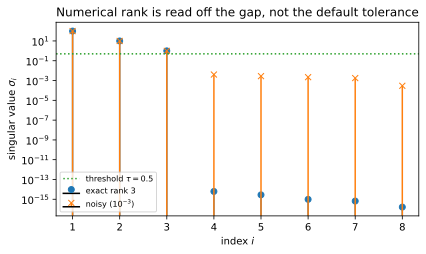

In [2]:
#| label: fig-numerical-rank
#| cap: "**Singular-value spectrum.** A rank-3 matrix (circles) and the same matrix with $10^{-3}$ additive noise (crosses). The machine-level default tolerance misreads the noisy matrix as full rank; a threshold in the three-decade gap between $\\sigma_3$ and $\\sigma_4$ recovers the rank 3."
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
m = n = 8
sigma = np.array([1e2, 1e1, 1e0])            # a clean 3-decade fall-off

U, _ = np.linalg.qr(rng.standard_normal((m, 3)))
V, _ = np.linalg.qr(rng.standard_normal((n, 3)))
A = (U * sigma) @ V.T                        # rank exactly 3
An = A + 1e-3 * rng.standard_normal((m, n))  # numerically full rank

s_exact = np.linalg.svd(A, compute_uv=False)
s_noisy = np.linalg.svd(An, compute_uv=False)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.stem(range(1, m + 1), s_exact, linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label='exact rank 3')
ax.stem(range(1, m + 1), s_noisy, linefmt='C1-', markerfmt='C1x', basefmt='k-',
        label='noisy ($10^{-3}$)')
ax.axhline(0.5, color='C2', ls=':', lw=1.5, label='threshold $\\tau = 0.5$')
ax.set_yscale('log')
ax.set_xlabel('index $i$')
ax.set_ylabel('singular value $\\sigma_i$')
ax.set_title('Numerical rank is read off the gap, not the default tolerance')
ax.legend(loc='lower left', fontsize=8)

print('rank(exact)              =', np.linalg.matrix_rank(A))
print('rank(noisy, default tol) =', np.linalg.matrix_rank(An))
print('rank(noisy, tol=0.5)     =', np.linalg.matrix_rank(An, tol=0.5))
print('sigma(noisy)             =', np.round(s_noisy, 4))


The exact spectrum decays as $10^2,10^1,10^0,0,0,\dots$; the noisy spectrum replaces each trailing zero with a value near $10^{-3}$. NumPy's default tolerance, $\sigma_1\,\varepsilon_{\text{mach}}\max(m,n)\approx10^{-13}$, sits far *below* the noise floor, so the default declares the noisy matrix full rank (8) even though it is rank 3 in every meaningful sense. The correct reading is visual: the spectrum has a three-decade gap between $\sigma_3=1$ and $\sigma_4\approx4\times10^{-3}$, and any threshold placed inside that gap recovers the rank. The gap is what makes rank well-posed; without one, the number is a modeling choice rather than a fact of the data.


**Full rank by shifting.** A rank-deficient square matrix is a hair's breadth from full rank: adding $\lambda\mathbf{I}$ moves every eigenvalue by $\lambda$, so $\mathbf{A}+\lambda\mathbf{I}$ is invertible whenever $-\lambda$ is not an eigenvalue. This is the **ridge shift** behind regularization, the same operation that stabilizes least squares in Chapter 8. The tension is real: too large a $\lambda$ makes $\mathbf{A}+\lambda\mathbf{I}\approx\lambda\mathbf{I}$, drowning the data; too small a $\lambda$ leaves the matrix nearly singular. It is not a defect of the method but the unavoidable trade of a little bias for a lot of stability (the balance is struck in Chapters 8 and 10).


**Demonstration: the CR decomposition.** Starting from a known rank-$r$ matrix and selecting its $r$ pivot columns reproduces the factorization exactly. The code below verifies that the selected $\mathbf{C}$ has independent columns and that $\mathbf{C}\mathbf{R}$ reconstructs $\mathbf{A}$ to machine precision.


In [3]:
import numpy as np
import scipy.linalg as la

rng = np.random.default_rng(1)
m, n, r = 6, 5, 3

C = rng.standard_normal((m, r))
R = rng.standard_normal((r, n))
A = C @ R                       # rank exactly r (generic)

# column-pivoted QR selects r independent columns of A
_, _, p = la.qr(A, pivoting=True, mode='economic')
piv = p[:r]                     # pivot columns
Csel = A[:, piv]
Rrec = np.linalg.lstsq(Csel, A, rcond=None)[0]

print('pivot columns      =', piv)
print('rank(Csel)         =', np.linalg.matrix_rank(Csel))
print('||A - Csel @ Rrec||=', np.linalg.norm(A - Csel @ Rrec))


pivot columns      = [1 4 2]
rank(Csel)         = 3
||A - Csel @ Rrec||= 3.0587302319905436e-15


Column-pivoted QR chooses pivot columns that are maximally independent, and the least-squares solve then reads off the $\mathbf{R}$ such that $\mathbf{A}=\mathbf{C}_{\text{sel}}\mathbf{R}_{\text{rec}}$ to machine precision. The reconstruction error of about $10^{-15}$ confirms the exactness of the skeleton representation: a $6\times5$ matrix carrying thirty entries is reproduced by three pivot columns and a $3\times5$ coefficient matrix — thirty-three numbers in all, *more* than the original at this tiny size. The representation pays off only once the rank is small relative to both dimensions, $r(m+n) \ll mn$; this is the arithmetic behind low-rank compression.


## The four fundamental subspaces

Every $\mathbf{A}\in\mathbb{R}^{m\times n}$ induces four subspaces, two in each space:

| Subspace | Notation | Lives in | dimension |
|---|---|---|---|
| column space | $\mathsf{C}(\mathbf{A})$ | $\mathbb{R}^m$ | $r$ |
| null space | $\mathsf{N}(\mathbf{A})$ | $\mathbb{R}^n$ | $n-r$ |
| row space | $\mathsf{C}(\mathbf{A}^{\mathsf T})$ | $\mathbb{R}^n$ | $r$ |
| left null space | $\mathsf{N}(\mathbf{A}^{\mathsf T})$ | $\mathbb{R}^m$ | $m-r$ |

The dimensions in the right column come from rank-nullity applied to $\mathbf{A}$ and to $\mathbf{A}^{\mathsf T}$, together with row rank equals column rank.


**Theorem (fundamental theorem of linear algebra, I).** The four subspaces decompose the input and output spaces orthogonally:

$$\mathbb{R}^n = \mathsf{C}(\mathbf{A}^{\mathsf T})\oplus\mathsf{N}(\mathbf{A}), \qquad \mathbb{R}^m = \mathsf{C}(\mathbf{A})\oplus\mathsf{N}(\mathbf{A}^{\mathsf T}),$$

with $\mathsf{C}(\mathbf{A}^{\mathsf T})\perp\mathsf{N}(\mathbf{A})$ and $\mathsf{C}(\mathbf{A})\perp\mathsf{N}(\mathbf{A}^{\mathsf T})$.

**Proof.** Orthogonality is the whole argument. A vector $\mathbf{x}$ lies in $\mathsf{N}(\mathbf{A})$ exactly when $\mathbf{A}\mathbf{x}=\mathbf{0}$, that is, when $\mathbf{x}$ is orthogonal to every *row* of $\mathbf{A}$; and the rows of $\mathbf{A}$ span $\mathsf{C}(\mathbf{A}^{\mathsf T})$. Therefore

$$\mathsf{N}(\mathbf{A}) = \mathsf{C}(\mathbf{A}^{\mathsf T})^{\perp}.$$

Since a subspace and its orthogonal complement always satisfy $V\oplus V^{\perp}=\mathbb{R}^n$, the first decomposition follows. The second is the same sentence with $\mathbf{A}^{\mathsf T}$ in place of $\mathbf{A}$. $\square$


**Explicit bases via the SVD.** Orthogonality is cheap; explicit bases need the SVD. With $\mathbf{A}=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ and $r=\text{rank}(\mathbf{A})$:

$$\mathsf{C}(\mathbf{A}^{\mathsf T}) = \operatorname{span}\{\mathbf{v}_1,\dots,\mathbf{v}_r\}, \qquad \mathsf{N}(\mathbf{A}) = \operatorname{span}\{\mathbf{v}_{r+1},\dots,\mathbf{v}_n\},$$

$$\mathsf{C}(\mathbf{A}) = \operatorname{span}\{\mathbf{u}_1,\dots,\mathbf{u}_r\}, \qquad \mathsf{N}(\mathbf{A}^{\mathsf T}) = \operatorname{span}\{\mathbf{u}_{r+1},\dots,\mathbf{u}_m\}.$$

Each line is verified directly: $\mathbf{A}^{\mathsf T}\mathbf{u}_i=\sigma_i\mathbf{v}_i$ puts $\mathbf{v}_1,\dots,\mathbf{v}_r$ in $\mathsf{C}(\mathbf{A}^{\mathsf T})$; $\mathbf{A}\mathbf{v}_i=\mathbf{0}$ for $i>r$ puts $\mathbf{v}_{r+1},\dots,\mathbf{v}_n$ in $\mathsf{N}(\mathbf{A})$; and the counts ($r$ and $n-r$) match the dimensions, so these spanning sets are bases. The same holds on the output side. This is the **basis table** of the four subspaces.


**What a matrix does.** Assembling the pieces: $\mathbf{A}$ acts on $\mathbb{R}^n=\mathsf{C}(\mathbf{A}^{\mathsf T})\oplus\mathsf{N}(\mathbf{A})$ by

- carrying the row space $\mathsf{C}(\mathbf{A}^{\mathsf T})$ bijectively onto the column space $\mathsf{C}(\mathbf{A})$, stretching each direction $\mathbf{v}_i$ by $\sigma_i$ and rotating $\mathbf{v}_i\mapsto\mathbf{u}_i$;
- collapsing the null space $\mathsf{N}(\mathbf{A})$ entirely to $\mathbf{0}$.

This is the cleanest one-line summary of a linear map: *rotate-and-stretch the information-carrying directions, annihilate the rest.* The null space is the information $\mathbf{A}$ destroys; the row space is the information it preserves.


Text(0.5, 1.0, '$\\mathbf{A}\\mathbf{x} = \\mathbf{A}\\mathbf{x}_{\\mathrm{row}}$')

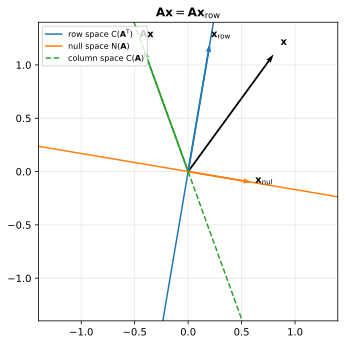

In [4]:
#| label: fig-four-subspaces
#| cap: "**The subspaces of a rank-1 map.** A rank-1 matrix $\\mathbf{A}=\\mathbf{u}\\mathbf{v}^{\\mathsf T}$ on $\\mathbb{R}^2$ collapses the null space (the line orthogonal to $\\mathbf{v}$) to the origin and carries the row space (the line spanned by $\\mathbf{v}$) onto the column space (the line spanned by $\\mathbf{u}$); the fourth subspace, the left null space (the line orthogonal to $\\mathbf{u}$), is its mirror and is not drawn. Any $\\mathbf{x}$ splits into a row-space part plus a null-space part, and only the first survives."
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2)
u = rng.standard_normal(2); u /= np.linalg.norm(u)
v = rng.standard_normal(2); v /= np.linalg.norm(v)
A = np.outer(u, v)                        # rank 1

x = np.array([0.8, 1.1])
x_row = (v @ x) * v                       # projection onto row space C(A^T)
x_nul = x - x_row                         # in N(A)

fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.axline((0, 0), v, color='C0', lw=1.5,
          label='row space $\\mathrm{C}(\\mathbf{A}^{\\mathrm{T}})$')
ax.axline((0, 0), np.array([-v[1], v[0]]), color='C1', lw=1.5,
          label='null space $\\mathrm{N}(\\mathbf{A})$')
ax.axline((0, 0), u, color='C2', lw=1.5, ls='--',
          label='column space $\\mathrm{C}(\\mathbf{A})$')

ax.quiver(0, 0, *x, angles='xy', scale_units='xy', scale=1, color='k', width=0.006)
ax.quiver(0, 0, *x_row, angles='xy', scale_units='xy', scale=1, color='C0', width=0.006)
ax.quiver(0, 0, *x_nul, angles='xy', scale_units='xy', scale=1, color='C1', width=0.006)
ax.quiver(0, 0, *(A @ x), angles='xy', scale_units='xy', scale=1, color='C2', width=0.006)

ax.annotate('$\\mathbf{x}$', x * 1.08)
ax.annotate('$\\mathbf{x}_{\\mathrm{row}}$', x_row * 1.05)
ax.annotate('$\\mathbf{x}_{\\mathrm{nul}}$', x_nul * 1.05)
ax.annotate('$\\mathbf{A}\\mathbf{x}$', (A @ x) * 1.1)

ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('$\\mathbf{A}\\mathbf{x} = \\mathbf{A}\\mathbf{x}_{\\mathrm{row}}$')


**Solutions of $\mathbf{A}\mathbf{x}=\mathbf{y}$.** The orthogonal decomposition makes the solution set of a linear system transparent. For $\mathbf{y}\in\mathsf{C}(\mathbf{A})$, the solutions are

$$\mathbf{x} = \mathbf{h} + \sum_{k=1}^{n-r} c_k \mathbf{v}_{r+k},$$

where $\mathbf{h}$ is any single (particular) solution and the $c_k$ are $n-r$ free parameters ranging over the null space. In the row-reduction picture the coordinates $c_k$ are the **free variables**, and each basis vector $\mathbf{v}_{r+k}$ solves the homogeneous system $\mathbf{A}\mathbf{x}=\mathbf{0}$ while $\mathbf{h}$ is the particular solution of $\mathbf{A}\mathbf{x}=\mathbf{y}$. The particular solution of smallest norm is the one with zero null-space component, $\mathbf{h}\in\mathsf{C}(\mathbf{A}^{\mathsf T})$: the **minimum-norm solution** $\mathbf{x}^{\dagger}=\mathbf{V}_r\boldsymbol{\Sigma}_r^{-1}\mathbf{U}_r^{\mathsf T}\mathbf{y}$, the pseudoinverse of Chapter 6.


In [5]:
import numpy as np

rng = np.random.default_rng(3)
m, n, r = 4, 5, 2

U, _ = np.linalg.qr(rng.standard_normal((m, r)))
V, _ = np.linalg.qr(rng.standard_normal((n, r)))
sig = np.array([3.0, 1.0])
A = (U * sig) @ V.T                       # rank 2, shape 4x5

y = A @ rng.standard_normal(n)            # a right-hand side in C(A)

u, s, vh = np.linalg.svd(A, full_matrices=False)
x_dag = (vh[:r].T / s[:r]) @ (u[:, :r].T @ y)  # minimum-norm solution (preview of Ch.6)

null_basis = vh[r:].T                     # (n, n-r) columns span N(A)
c = np.array([[0.0, 0.0], [1.0, -0.5], [-2.0, 0.7]])
solns = x_dag[:, None] + null_basis @ c.T # (n, 3) shifted solutions

residuals = A @ solns - y[:, None]
print('||A @ x_dag - y||        =', np.linalg.norm(A @ x_dag - y))
print('max ||A @ x_k - y|| over 3 =', np.max(np.linalg.norm(residuals, axis=0)))
print('norms (min-norm, shifted) =',
      np.round([np.linalg.norm(x_dag), *np.linalg.norm(solns, axis=0)], 4))


||A @ x_dag - y||        = 4.577566798522237e-16
max ||A @ x_k - y|| over 3 = 6.377745716588144e-16
norms (min-norm, shifted) = [1.5079 1.5079 1.8772 2.6007]


Every solution is $\mathbf{x}^{\dagger}$ plus a point of the null space, so all three shifted vectors reproduce $\mathbf{y}$ exactly (residual about $10^{-15}$); their norms, however, strictly exceed $\|\mathbf{x}^{\dagger}\|$, confirming that the SVD's particular solution is the minimum-norm one. The null space is the *ambiguity* in the system, the information $\mathbf{y}$ cannot pin down; the row space is the information it does.


## Summary

- **Rank** is the dimension of the image; it is well-defined because the exchange lemma forces all bases to share a cardinality.
- **Rank-nullity**, $\dim\mathsf{N}(\mathbf{A})+\text{rank}(\mathbf{A})=n$, is the accounting identity of a linear map.
- **Row rank equals column rank**, provable abstractly through $\mathsf{N}(\mathbf{A}^{\mathsf T}\mathbf{A})=\mathsf{N}(\mathbf{A})$ and read off instantly from the SVD.
- **Numerically**, rank is a count at a tolerance: the singular-value spectrum and its gaps decide how well-posed the question is.
- **The four fundamental subspaces** decompose $\mathbb{R}^n$ and $\mathbb{R}^m$ orthogonally; the SVD supplies explicit bases. A matrix rotates-and-stretches its row space onto its column space and annihilates its null space.
- The solution set of $\mathbf{A}\mathbf{x}=\mathbf{y}$ is a particular solution plus the null space; the minimum-norm member is the pseudoinverse of Chapter 6.


## Problems

Each problem uses the notation of this chapter: $\mathsf{C}(\cdot)$ for column and row spaces, $\mathsf{N}(\cdot)$ for null spaces, and $\text{rank}(\cdot)$ for the common dimension. Problems 1–2 are theory, 3–4 are short numerical checks, and Problem 5 is a numerical experiment.


### [P4.1] Rank of a product

Let $\mathbf{A}\in\mathbb{R}^{m\times n}$ and $\mathbf{B}\in\mathbb{R}^{n\times p}$.

(a) Prove $\text{rank}(\mathbf{A}\mathbf{B})\le\text{rank}(\mathbf{A})$ by showing that every column of $\mathbf{A}\mathbf{B}$ is a linear combination of the columns of $\mathbf{A}$, hence $\mathsf{C}(\mathbf{A}\mathbf{B})\subseteq\mathsf{C}(\mathbf{A})$.

(b) Prove $\text{rank}(\mathbf{A}\mathbf{B})\le\text{rank}(\mathbf{B})$ by applying part (a) to the transposes and using row rank equals column rank.

(c) Suppose $\mathbf{A}$ has full column rank, $\text{rank}(\mathbf{A})=n$. Prove $\text{rank}(\mathbf{A}\mathbf{B})=\text{rank}(\mathbf{B})$. *Hint:* show $\mathsf{N}(\mathbf{A}\mathbf{B})=\mathsf{N}(\mathbf{B})$ and apply rank-nullity.

In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** (n) Rnpu pbyhza bs NO vf N gvzrf n pbyhza bs O, urapr n yvarne pbzovangvba bs gur pbyhzaf bs N, fb P(NO) ⊆ P(N) naq enax(NO) ≤ enax(N). (o) enax(NO) = enax((NO)^G) = enax(O^G N^G) ≤ enax(O^G) = enax(O), hfvat cneg (n) naq ebj enax rdhnyf pbyhza enax. (p) A(O) ⊆ A(NO) vf vzzrqvngr. Pbairefryl, vs NOk = 5 gura Ok ∈ A(N); fvapr enax N = a, enax-ahyyvgl tvirf qvz A(N) = 5, fb Ok = 5 naq k ∈ A(O). Urapr A(NO) = A(O), naq enax-ahyyvgl nccyvrq gb O tvirf enax(NO) = c − qvz A(NO) = c − qvz A(O) = enax(O).

# **Nafjre:** enax(NO) ≤ zva(enax N, enax O); rdhnyvgl enax(NO) = enax(O) jura N unf shyy pbyhza enax.

### [P4.2] The subspaces of $\mathbf{A}^{\mathsf T}\mathbf{A}$

Let $\mathbf{A}\in\mathbb{R}^{m\times n}$.

(a) Prove $\mathsf{N}(\mathbf{A}\mathbf{A}^{\mathsf T})=\mathsf{N}(\mathbf{A}^{\mathsf T})$ by the norm argument used in the chapter for $\mathbf{A}^{\mathsf T}\mathbf{A}$: if $\mathbf{A}\mathbf{A}^{\mathsf T}\mathbf{x}=\mathbf{0}$, then $\lVert\mathbf{A}^{\mathsf T}\mathbf{x}\rVert^2=\mathbf{x}^{\mathsf T}\mathbf{A}\mathbf{A}^{\mathsf T}\mathbf{x}=0$.

(b) Prove $\mathsf{C}(\mathbf{A}^{\mathsf T}\mathbf{A})=\mathsf{C}(\mathbf{A}^{\mathsf T})$ and $\mathsf{C}(\mathbf{A}\mathbf{A}^{\mathsf T})=\mathsf{C}(\mathbf{A})$. *Hint:* take orthogonal complements in part (a) and in the chapter's identity $\mathsf{N}(\mathbf{A}^{\mathsf T}\mathbf{A})=\mathsf{N}(\mathbf{A})$, then apply the fundamental theorem of linear algebra.

(c) Conclude $\text{rank}(\mathbf{A}^{\mathsf T}\mathbf{A})=\text{rank}(\mathbf{A})=\text{rank}(\mathbf{A}\mathbf{A}^{\mathsf T})$.

In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** (n) A(NN^G) ⊆ A(N^G) vf vzzrqvngr. Vs NN^G k = 5, gura ||N^G k||^7 = k^G NN^G k = 5, fb N^G k = 5; urapr A(NN^G) = A(N^G). (o) Gnxr begubtbany pbzcyrzragf va cneg (n) naq va gur puncgre'f vqragvgl A(N^G N) = A(N): P(NN^G) = A((NN^G)^G)^⊥ = A(NN^G)^⊥ = A(N^G)^⊥ = P(N), naq P(N^G N) = A(N^G N)^⊥ = A(N)^⊥ = P(N^G), hfvat gur shaqnzragny gurberz A(N^G)^⊥ = P(N) naq A(N)^⊥ = P(N^G). (p) enax(N^G N) = a − qvz A(N^G N) = a − qvz A(N) = enax(N), naq enax(NN^G) = z − qvz A(NN^G) = z − qvz A(N^G) = enax(N^G) = enax(N).

# **Nafjre:** enax(N^G N) = enax(N) = enax(NN^G).

### [P4.3] Numerical rank from the spectrum

Construct an $8\times8$ matrix $\mathbf{A}$ of exact rank 3 with singular values $10^2,10^1,10^0$, then add $10^{-3}$ additive noise. Compare three rank estimates: the exact rank, the default-tolerance rank of the noisy matrix, and the rank at a threshold placed inside the spectral gap. The starter code below prints all three alongside the noisy spectrum.

In [1]:
import numpy as np

rng = np.random.default_rng(0)
m = n = 8
sigma = np.array([1e2, 1e1, 1e0])

U, _ = np.linalg.qr(rng.standard_normal((m, 3)))
V, _ = np.linalg.qr(rng.standard_normal((n, 3)))
A = (U * sigma) @ V.T
An = A + 1e-3 * rng.standard_normal((m, n))

s = np.linalg.svd(An, compute_uv=False)

rank_exact = np.linalg.matrix_rank(A)
rank_default = np.linalg.matrix_rank(An)
rank_gap = np.linalg.matrix_rank(An, tol=0.5)

print('rank(exact)              =', rank_exact)
print('rank(noisy, default tol) =', rank_default)
print('rank(noisy, tol=0.5)     =', rank_gap)
print('sigma(noisy)             =', np.round(s, 4))


rank(exact)              = 3
rank(noisy, default tol) = 8
rank(noisy, tol=0.5)     = 3
sigma(noisy)             = [9.99996e+01 9.99940e+00 1.00040e+00 4.00000e-03 2.80000e-03 2.20000e-03
 1.80000e-03 3.00000e-04]


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** Gur rknpg zngevk unf enax 8. Gur abvfl fcrpgehz vf [6r7, 6r6, 6.5559, 9r-8, 7.3r-8, 7.7r-8, 6.3r-8, 8r-9]: gur genvyvat mrebf ner ercynprq ol inyhrf arne 6r-8. AhzCl'f qrsnhyg gbyrenapr (≈ fvtzn_6 * rcf_znpu * znk(z,a) ≈ 6r-68) fvgf orybj gur abvfr sybbe, fb vg qrpynerf gur abvfl zngevk shyy enax (3). N guerfubyq bs 5.0 fvgf vafvqr gur guerr-qrpnqr tnc orgjrra fvtzn_8 ≈ 6 naq fvtzn_9 ≈ 9r-8 naq erpbiref gur gehr enax 8.

# **Nafjre:** enax(rknpg) = 8, enax(abvfl, qrsnhyg gby) = 3, enax(abvfl, gby=5.0) = 8

# **Purpxf:**
# - ahzrevpny enax ng guerfubyq 5.0 vafvqr gur fcrpgeny tnc: rkcrpgrq 8 ± 5
# - qrsnhyg-gbyrenapr enax bs gur abvfl zngevk: rkcrpgrq 3 ± 5

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac

# eat = ac.enaqbz.qrsnhyg_eat(5)
# z = a = 3
# fvtzn = ac.neenl([6r7, 6r6, 6r5])

# H, _ = ac.yvanyt.de(eat.fgnaqneq_abezny((z, 8)))
# I, _ = ac.yvanyt.de(eat.fgnaqneq_abezny((a, 8)))
# N = (H * fvtzn) @ I.G
# Na = N + 6r-8 * eat.fgnaqneq_abezny((z, a))

# f = ac.yvanyt.fiq(Na, pbzchgr_hi=Snyfr)
# enax_rknpg = ac.yvanyt.zngevk_enax(N)
# enax_qrsnhyg = ac.yvanyt.zngevk_enax(Na)
# enax_tnc = ac.yvanyt.zngevk_enax(Na, gby=5.0)

# nffreg enax_rknpg == 8
# nffreg enax_qrsnhyg == 3
# nffreg enax_tnc == 8
# nffreg f[8] < 6r-7 < f[7]   # guerfubyq 5.0 fvgf vafvqr gur tnc
# cevag('enax(rknpg)=8, enax(qrsnhyg)=3, enax(gby=5.0)=8')
# ```

The exact spectrum is $10^2,10^1,10^0,0,\dots$; the noisy spectrum replaces the trailing zeros with values near $10^{-3}$. The default tolerance sits below the noise floor and declares the noisy matrix full rank, while a threshold inside the three-decade gap recovers the true rank 3.


### [P4.4] The CR decomposition

Build a rank-3 matrix $\mathbf{A}=\mathbf{C}\mathbf{R}$ with $\mathbf{C}\in\mathbb{R}^{6\times3}$ and $\mathbf{R}\in\mathbb{R}^{3\times5}$, then recover the skeleton: select the $r$ pivot columns of $\mathbf{A}$ by column-pivoted QR and solve for the coefficient matrix. The starter code below prints the pivot columns, the rank of the selected column matrix, and the reconstruction error.

In [1]:
import numpy as np
import scipy.linalg as la

rng = np.random.default_rng(1)
m, n, r = 6, 5, 3

C = rng.standard_normal((m, r))
R = rng.standard_normal((r, n))
A = C @ R

_, _, p = la.qr(A, pivoting=True, mode='economic')
piv = p[:r]
Csel = A[:, piv]
Rrec = np.linalg.lstsq(Csel, A, rcond=None)[0]

print('pivot columns      =', piv)
print('rank(Csel)         =', np.linalg.matrix_rank(Csel))
print('||A - Csel @ Rrec||=', np.linalg.norm(A - Csel @ Rrec))


pivot columns      = [1 4 2]
rank(Csel)         = 3
||A - Csel @ Rrec||= 3.0587302319905436e-15


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** Pbyhza-cvibgrq DE fryrpgf gur cvibg pbyhzaf [6 9 7] (5-onfrq), juvpu ner znkvznyyl vaqrcraqrag, fb enax(Pfry) = 8. Gur yrnfg-fdhnerf fbyir ernqf bss gur pbrssvpvrag zngevk Eerp fhpu gung N = Pfry @ Eerp gb znpuvar cerpvfvba: gur erpbafgehpgvba reebe vf nobhg 8.6r-60, pbasvezvat gur rknpgarff bs gur fxryrgba ercerfragngvba.

# **Nafjre:** cvibg pbyhzaf [6 9 7], enax(Pfry) = 8, ||N - Pfry @ Eerp|| ≈ 8.51r-60

# **Purpxf:**
# - enax bs gur fryrpgrq cvibg pbyhzaf: rkcrpgrq 8 ± 5
# - erpbafgehpgvba reebe ||N - Pfry @ Eerp||: rkcrpgrq 5.5 ± 6r-67

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac
# vzcbeg fpvcl.yvanyt nf yn

# eat = ac.enaqbz.qrsnhyg_eat(6)
# z, a, e = 1, 0, 8

# P = eat.fgnaqneq_abezny((z, e))
# E = eat.fgnaqneq_abezny((e, a))
# N = P @ E

# _, _, c = yn.de(N, cvibgvat=Gehr, zbqr='rpbabzvp')
# cvi = c[:e]
# Pfry = N[:, cvi]
# Eerp = ac.yvanyt.yfgfd(Pfry, N, epbaq=Abar)[5]

# ree = ac.yvanyt.abez(N - Pfry @ Eerp)
# nffreg ac.yvanyt.zngevk_enax(Pfry) == 8
# nffreg ree < 6r-67
# cevag('cvibg pbyhzaf =', cvi, ' enax(Pfry)=8, reebe =', ree)
# ```

The selected columns are maximally independent, so $\text{rank}(\mathbf{C}_{\text{sel}})=3$, and the least-squares solve recovers $\mathbf{R}$ to machine precision: the reconstruction error sits near $10^{-15}$, confirming the exactness of the skeleton representation.


### [P4.5] The gap decides the rank

**Challenge.** The chapter's figure examines a single noise level. This experiment sweeps the noise floor and locates where the rank stops being well-posed.

(a) For each $\varepsilon\in\{10^{-1},10^{-3},10^{-5}\}$, build the rank-3 matrix of Problem 3, add $\varepsilon$ times standard-normal noise, and record $\sigma_3$ and $\sigma_4$ of the noisy matrix.

(b) For each $\varepsilon$, place a threshold at the geometric midpoint $\tau=\sqrt{\sigma_3\sigma_4}$ of the gap and report the numerical rank at that threshold, alongside the default-tolerance rank.

(c) Repeat with $\varepsilon=1$. Report $\sigma_3,\sigma_4$ and both ranks. The gap threshold still returns rank 3, but the recovered rank is now spurious: explain in one sentence why, given that $\sigma_4$ exceeds the smallest genuine singular value $\sigma_3(\mathbf{A})=1$. The starter code below runs the whole sweep.

In [1]:
import numpy as np

rng = np.random.default_rng(0)
m = n = 8
sigma = np.array([1e2, 1e1, 1e0])

U, _ = np.linalg.qr(rng.standard_normal((m, 3)))
V, _ = np.linalg.qr(rng.standard_normal((n, 3)))
A = (U * sigma) @ V.T

for eps in [1e-1, 1e-3, 1e-5, 1.0]:
    An = A + eps * rng.standard_normal((m, n))
    s = np.linalg.svd(An, compute_uv=False)
    s3, s4 = s[2], s[3]
    tau = np.sqrt(s3 * s4)
    rank_gap = np.linalg.matrix_rank(An, tol=tau)
    rank_default = np.linalg.matrix_rank(An)
    print(f'eps={eps:6.1e}  sigma3={s3:9.4f}  sigma4={s4:9.4f}  '
          f'rank(tau)={rank_gap}  rank(default)={rank_default}')


eps=1.0e-01  sigma3=   1.0749  sigma4=   0.4020  rank(tau)=3  rank(default)=8
eps=1.0e-03  sigma3=   1.0000  sigma4=   0.0032  rank(tau)=3  rank(default)=8
eps=1.0e-05  sigma3=   1.0000  sigma4=   0.0000  rank(tau)=3  rank(default)=8
eps=1.0e+00  sigma3=   4.8870  sigma4=   3.3216  rank(tau)=3  rank(default)=8


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** Sbe rcf = 6r-6, 6r-8, 6r-0 gur abvfr sybbe fvtzn_9 (5.95, 8.7r-8, ~5) fvgf orybj gur fznyyrfg trahvar fvathyne inyhr fvtzn_8(N) = 6, fb gur tnc-zvqcbvag guerfubyq erpbiref enax 8 juvyr gur qrsnhyg gbyrenapr ercbegf 3: gur enax vf jryy-cbfrq. Ng rcf = 6 gur abvfr sybbe (fvtzn_9 ≈ 8.87) rkprrqf fvtzn_8(N) = 6, fb gur guveq fvathyne inyhr bs gur abvfl zngevk (9.34) vf n abvfr qverpgvba, abg n trahvar bar; gur enax 8 erpbirerq ol gur tnc guerfubyq vf fchevbhf naq gur zngevk vf trahvaryl shyy enax (3). Gur qvntabfgvp vf jurgure fvtzn_9 < fvtzn_8(N), abg zreryl jurgure n tnc rkvfgf.

# **Nafjre:** enax(gnh) = 8 sbe nyy rcf, ohg fchevbhf ng rcf = 6 jurer fvtzn_9 ≈ 8.87 > fvtzn_8(N) = 6

# **Purpxf:**
# - ahzrevpny enax ng tnc-zvqcbvag guerfubyq sbe rcf=6r-8: rkcrpgrq 8 ± 5
# - fvtzn_9 sbe rcf=6 rkprrqf gur trahvar fvtzn_8(N)=6 (erpbirerq enax fchevbhf): rkcrpgrq 8.87 ± 5.0

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac

# eat = ac.enaqbz.qrsnhyg_eat(5)
# z = a = 3
# fvtzn = ac.neenl([6r7, 6r6, 6r5])

# H, _ = ac.yvanyt.de(eat.fgnaqneq_abezny((z, 8)))
# I, _ = ac.yvanyt.de(eat.fgnaqneq_abezny((a, 8)))
# N = (H * fvtzn) @ I.G

# erfhygf = {}
# sbe rcf va [6r-6, 6r-8, 6r-0, 6.5]:
#     Na = N + rcf * eat.fgnaqneq_abezny((z, a))
#     f = ac.yvanyt.fiq(Na, pbzchgr_hi=Snyfr)
#     f8, f9 = f[7], f[8]
#     gnh = ac.fdeg(f8 * f9)
#     enax_tnc = ac.yvanyt.zngevk_enax(Na, gby=gnh)
#     enax_qrsnhyg = ac.yvanyt.zngevk_enax(Na)
#     erfhygf[rcf] = (f8, f9, enax_tnc, enax_qrsnhyg)

# # jryy-cbfrq pnfrf: abvfr sybbe orybj gur trahvar fvtzn_8(N) = 6
# sbe rcf va [6r-6, 6r-8, 6r-0]:
#     f8, f9, et, eq = erfhygf[rcf]
#     nffreg f9 < 6.5 naq et == 8 naq eq == 3
# # rcf = 6: abvfr sybbe rkprrqf fvtzn_8(N) = 6, erpbirerq enax vf fchevbhf
# f8, f9, et, eq = erfhygf[6.5]
# nffreg f9 > 6.5 naq eq == 3
# cevag('jryy-cbfrq sbe rcf<=6r-6 (enax 8 erpbirenoyr); fchevbhf ng rcf=6')
# ```

For $\varepsilon\le10^{-1}$ the noise floor $\sigma_4$ sits below the smallest genuine singular value $\sigma_3(\mathbf{A})=1$, so the gap threshold recovers the true rank 3 while the default tolerance reports 8. At $\varepsilon=1$ the noise floor ($\sigma_4\approx3.3$) exceeds $\sigma_3(\mathbf{A})=1$: the third singular value of the noisy matrix is a noise direction, so the rank 3 recovered by the gap threshold is spurious and the matrix is genuinely full rank.
